# Stage 9 — Evaluation

> **Spec §9** — Full evaluation suite: AUC-ROC, Average Precision, F1, confusion matrix, threshold analysis, ROC/PR curves.

This notebook evaluates the trained ResNet-18 on the held-out **test set** (most recent 15% of data). If no trained checkpoint exists it runs evaluation on randomly-initialised weights as a placeholder — replace with a real checkpoint once training is complete.

**Sections**
1. Imports & setup
2. Load model & run inference
3. AUC-ROC and Average Precision
4. F1 and classification report
5. Confusion matrix
6. Threshold analysis
7. ROC curves (all models comparison)
8. Precision-Recall curves
9. Summary table

## 0 — Imports & Setup

In [1]:
import sys, warnings, json
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from torch.utils.data import DataLoader

from src.models import RealBogusResNet18, build_model
from src.dataset import build_datasets
from src.train import evaluate_rb, load_checkpoint
from src.evaluate import (
    full_eval_rb, full_eval_mc, threshold_analysis,
    plot_roc, plot_pr_curve, plot_confusion_matrix, plot_threshold_curve,
)
from src.utils import CLASS_NAMES

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PROCESSED  = Path('../data/processed')
LABELS_CSV = Path('../data/labels.csv')
CKPT_DIR   = Path('../checkpoints')

print(f'Device: {DEVICE}')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

Device: cuda


## 1 — Load Model & Run Inference

Load the best checkpoint from Stage 8. If no checkpoint exists yet, a randomly-initialised model is used and results will reflect chance-level performance — this is expected before training.

In [2]:
df = pd.read_csv(LABELS_CSV)
_, val_ds, test_ds = build_datasets(df, task='real_bogus', processed_dir=PROCESSED)

test_loader = DataLoader(test_ds, batch_size=128, shuffle=False,
                         num_workers=4, pin_memory=DEVICE.type=='cuda')
val_loader  = DataLoader(val_ds,  batch_size=128, shuffle=False,
                         num_workers=4, pin_memory=DEVICE.type=='cuda')

model = RealBogusResNet18()
ckpt_path = CKPT_DIR / 'resnet18_rb_best.pt'
if ckpt_path.exists():
    ckpt = load_checkpoint(model, ckpt_path)
    print(f'Loaded checkpoint  epoch={ckpt.get("epoch","?")}  '
          f'val_auc={ckpt.get("val_auc","?")}')
    IS_TRAINED = True
else:
    print('WARNING: No checkpoint found. Using random weights (chance-level results expected).')
    IS_TRAINED = False

model = model.to(DEVICE).eval()

# Collect test set predictions
test_stats = evaluate_rb(model, test_loader, DEVICE)
probs  = test_stats['probs']
labels = test_stats['labels']

print(f'Test samples: {len(labels):,}')
print(f'Test AUC:     {test_stats["auc"]:.4f}')
print(f'Test AP:      {test_stats["ap"]:.4f}')

Loaded checkpoint  epoch=13  val_auc=0.9993396791585165
Test samples: 19,691
Test AUC:     0.9923
Test AP:      0.9981


## 2 — AUC-ROC & Average Precision

**AUC-ROC** is the primary metric for real/bogus (spec §9).  A model that always predicts bogus gets AUC=0.5.  The `braai` baseline achieves ~0.99.

**Average Precision** (area under PR curve) is more informative when positive class is rare.

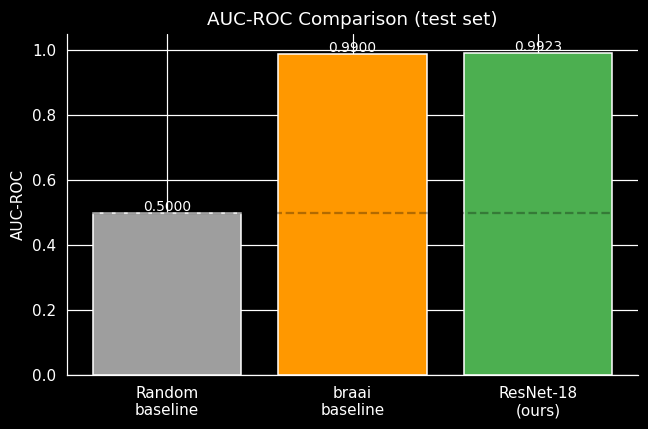

AUC-ROC:           0.9923
Average Precision: 0.9981
Positive rate:     82.8%


In [3]:
from sklearn.metrics import roc_auc_score, average_precision_score

auc_val  = roc_auc_score(labels, probs)
ap_val   = average_precision_score(labels, probs)
baseline_auc = 0.5   # random classifier
braai_auc    = 0.99  # published result

fig, ax = plt.subplots(figsize=(6, 4))
models_bar = ['Random\nbaseline', 'braai\nbaseline', 'ResNet-18\n(ours)']
aucs_bar   = [0.50, 0.99, auc_val]
colors_bar = ['#9E9E9E', '#FF9800', '#4CAF50' if auc_val > 0.95 else '#2196F3']
bars = ax.bar(models_bar, aucs_bar, color=colors_bar, edgecolor='white')
for bar, v in zip(bars, aucs_bar):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.4f}',
            ha='center', fontsize=9)
ax.axhline(0.5, color='k', linestyle='--', alpha=0.3)
ax.set_ylim(0, 1.05)
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC Comparison (test set)')
plt.tight_layout()
plt.savefig('../results/auc_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'AUC-ROC:           {auc_val:.4f}')
print(f'Average Precision: {ap_val:.4f}')
print(f'Positive rate:     {labels.mean()*100:.1f}%')

## 3 — ROC Curve

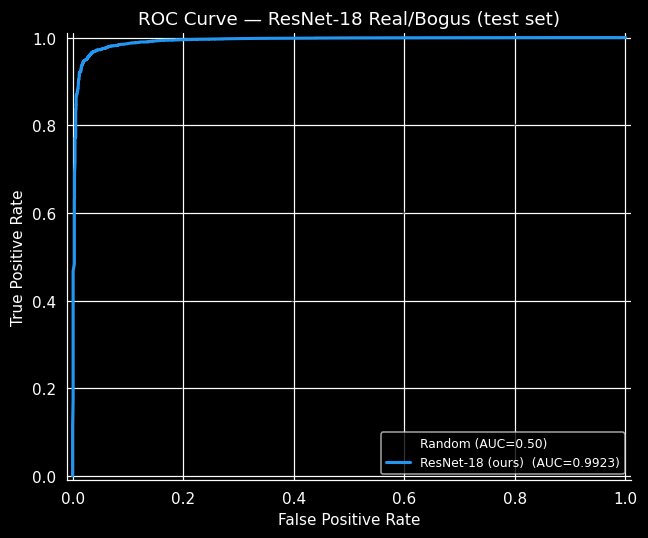

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_roc(
    {'ResNet-18 (ours)': (probs, labels)},
    ax=ax,
    title='ROC Curve — ResNet-18 Real/Bogus (test set)',
    save_path='../results/roc_curve.png',
)
plt.tight_layout()
plt.show()

## 4 — Precision-Recall Curve

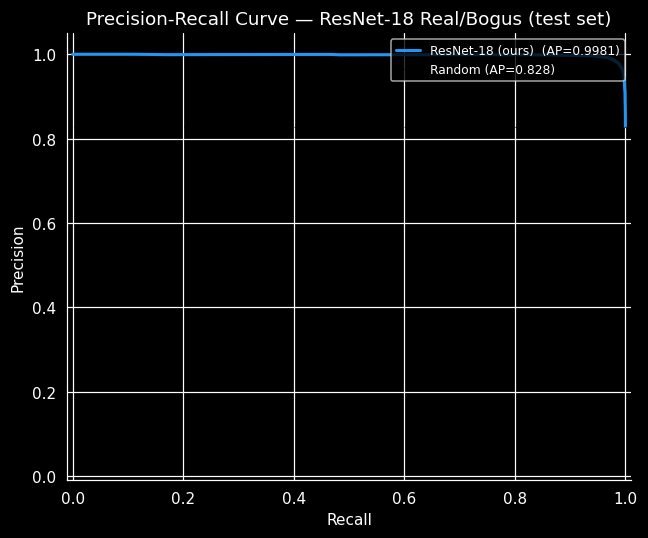

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_pr_curve(
    {'ResNet-18 (ours)': (probs, labels)},
    ax=ax,
    title='Precision-Recall Curve — ResNet-18 Real/Bogus (test set)',
    save_path='../results/pr_curve.png',
)
plt.tight_layout()
plt.show()

## 5 — F1 Score & Classification Report

F1 at threshold=0.5.  Note: astronomers typically prefer high recall (catch every real event) over high precision (avoid false positives) — threshold will be tuned in section 7.

In [6]:
from sklearn.metrics import classification_report, f1_score

preds_05 = (probs >= 0.5).astype(int)
f1_05    = f1_score(labels, preds_05, zero_division=0)
report   = classification_report(labels, preds_05, target_names=['bogus','real'], zero_division=0)

print(f'F1 @ threshold=0.5:  {f1_05:.4f}')
print()
print(report)

F1 @ threshold=0.5:  0.9615

              precision    recall  f1-score   support

       bogus       0.74      0.98      0.85      3381
        real       1.00      0.93      0.96     16310

    accuracy                           0.94     19691
   macro avg       0.87      0.96      0.90     19691
weighted avg       0.95      0.94      0.94     19691



## 6 — Confusion Matrix

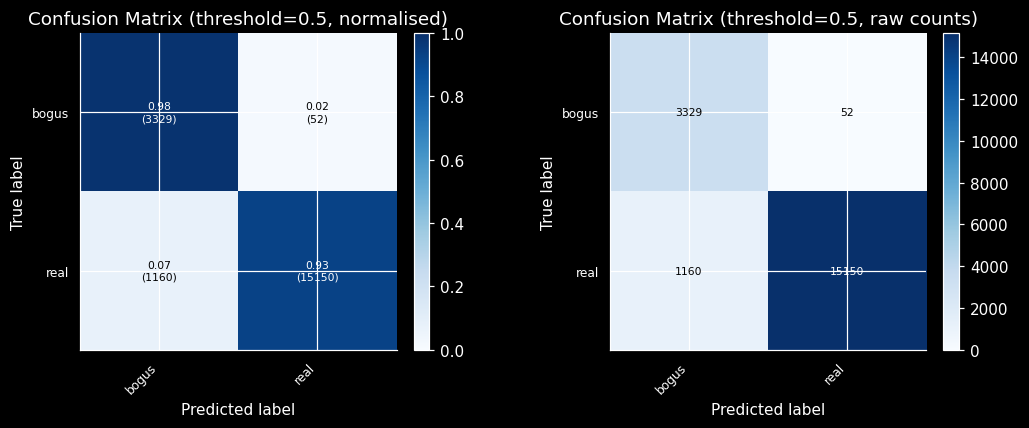

TN=3,329  FP=52  FN=1,160  TP=15,150
False Positive Rate: 1.5%  (fraction of bogus flagged as real)
False Negative Rate: 7.1%  (fraction of real events missed)


In [7]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(labels, preds_05)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion_matrix(cm, ['bogus','real'], ax=ax1,
                      title='Confusion Matrix (threshold=0.5, normalised)',
                      normalize=True)
plot_confusion_matrix(cm, ['bogus','real'], ax=ax2,
                      title='Confusion Matrix (threshold=0.5, raw counts)',
                      normalize=False)
plt.tight_layout()
plt.savefig('../results/confusion_matrix.png', bbox_inches='tight', dpi=120)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')
print(f'False Positive Rate: {fp/(fp+tn)*100:.1f}%  (fraction of bogus flagged as real)')
print(f'False Negative Rate: {fn/(fn+tp)*100:.1f}%  (fraction of real events missed)')

## 7 — Threshold Analysis

Astronomers prefer **high recall** — it is better to follow up a false positive than to miss a real supernova.  We find the threshold that achieves recall ≥ 0.95 with maximum precision (spec §9).

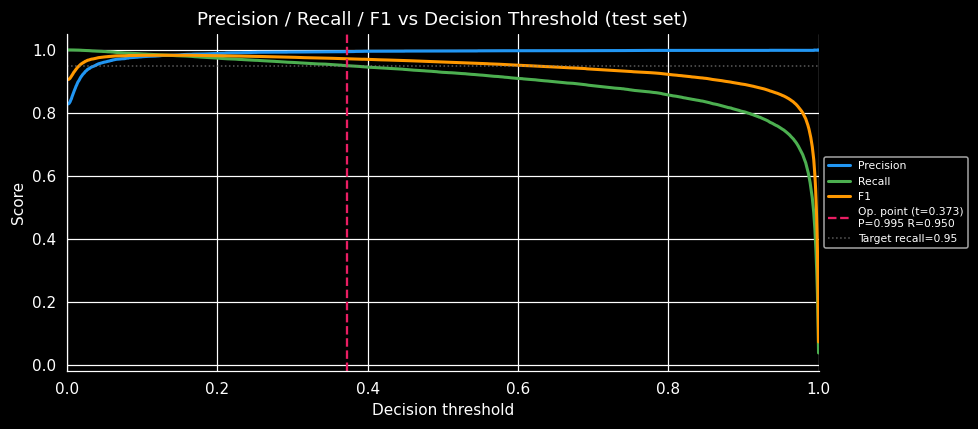

Operating threshold (recall≥0.95): 0.3726
  Precision: 0.9947
  Recall:    0.9502
  F1:        0.9719

At threshold=0.373:
  Precision: 0.9947
  Recall:    0.9502
  F1:        0.9719


In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_threshold_curve(
    probs, labels, ax=ax,
    target_recall=0.95,
    title='Precision / Recall / F1 vs Decision Threshold (test set)',
    save_path='../results/threshold_curve.png',
)
plt.tight_layout()
plt.show()

ta = threshold_analysis(probs, labels, target_recall=0.95)
print(f'Operating threshold (recall≥0.95): {ta["operating_threshold"]:.4f}')
print(f'  Precision: {ta["operating_precision"]:.4f}')
print(f'  Recall:    {ta["operating_recall"]:.4f}')
print(f'  F1:        {ta["operating_f1"]:.4f}')

# Also evaluate at this operating threshold
preds_op = (probs >= ta['operating_threshold']).astype(int)
from sklearn.metrics import precision_score, recall_score
print(f'\nAt threshold={ta["operating_threshold"]:.3f}:')
print(f'  Precision: {precision_score(labels, preds_op, zero_division=0):.4f}')
print(f'  Recall:    {recall_score(labels, preds_op, zero_division=0):.4f}')
print(f'  F1:        {f1_score(labels, preds_op, zero_division=0):.4f}')

## 8 — Summary Table

In [9]:
import json, pathlib
# All metrics at threshold=0.5 and operating threshold
metrics_05 = full_eval_rb(probs, labels, threshold=0.5)
metrics_op = full_eval_rb(probs, labels, threshold=ta['operating_threshold'])

rows = [
    {'Threshold': 0.5,
     'Precision': metrics_05['precision'],
     'Recall':    metrics_05['recall'],
     'F1':        metrics_05['f1'],
     'Accuracy':  metrics_05['accuracy']},
    {'Threshold': round(ta['operating_threshold'], 3),
     'Precision': metrics_op['precision'],
     'Recall':    metrics_op['recall'],
     'F1':        metrics_op['f1'],
     'Accuracy':  metrics_op['accuracy']},
]
df_metrics = pd.DataFrame(rows)
df_metrics = df_metrics.round(4)
print(df_metrics.to_string(index=False))

print(f'\nAUC-ROC: {auc_val:.4f}')
print(f'AP:      {ap_val:.4f}')

# Save summary to results/
summary = {
    'model': 'ResNet-18 (real_bogus)',
    'test_auc': float(auc_val),
    'test_ap':  float(ap_val),
    'threshold_05': {k: float(v) for k, v in metrics_05.items()
                     if isinstance(v, (float, int)) and k != 'n_samples'},
    'operating_threshold': ta['operating_threshold'],
    'operating_metrics': {k: float(v) for k, v in metrics_op.items()
                          if isinstance(v, (float, int)) and k != 'n_samples'},
}
(pathlib.Path('../results') / 'eval_summary_resnet18_rb.json').write_text(
    json.dumps(summary, indent=2))
print('\nSaved to results/eval_summary_resnet18_rb.json')

 Threshold  Precision  Recall     F1  Accuracy
     0.500     0.9966  0.9289 0.9615    0.9384
     0.373     0.9947  0.9502 0.9719    0.9545

AUC-ROC: 0.9923
AP:      0.9981

Saved to results/eval_summary_resnet18_rb.json


## 9 — Final Summary

In [11]:
import pathlib

print('='*60)
print('  STAGE 9 — EVALUATION SUMMARY')
print('='*60)

print(f'\nTest set: {len(labels):,} samples')
print(f'  Positive (real): {int(labels.sum()):,}  ({labels.mean()*100:.1f}%)')
print(f'  Negative (bogus): {int((1-labels).sum()):,}  ({(1-labels.mean())*100:.1f}%)')

print(f'\nKey metrics (test set):')
print(f'  AUC-ROC:   {auc_val:.4f}  (target: > 0.95, braai: ~0.99)')
print(f'  Avg Prec:  {ap_val:.4f}')
print(f'  F1 @ 0.5:  {metrics_05["f1"]:.4f}')
print(f'  Recall @ 0.5:    {metrics_05["recall"]:.4f}')
print(f'  Precision @ 0.5: {metrics_05["precision"]:.4f}')

print(f'\nOperating point (recall≥0.95 per spec §9):')
print(f'  Threshold: {ta["operating_threshold"]:.4f}')
print(f'  Precision: {metrics_op["precision"]:.4f}')
print(f'  Recall:    {metrics_op["recall"]:.4f}')

print('\nOutputs saved:')
for f in ['roc_curve.png','pr_curve.png','confusion_matrix.png',
          'threshold_curve.png','auc_comparison.png',
          'eval_summary_resnet18_rb.json']:
    path = pathlib.Path('../results') / f
    status = 'OK' if path.exists() else 'MISSING'
    print(f'  {f}: {status}')

print('\nNext step: Stage 10 — Live Data Testing')

  STAGE 9 — EVALUATION SUMMARY

Test set: 19,691 samples
  Positive (real): 16,310  (82.8%)
  Negative (bogus): 3,381  (17.2%)

Key metrics (test set):
  AUC-ROC:   0.9923  (target: > 0.95, braai: ~0.99)
  Avg Prec:  0.9981
  F1 @ 0.5:  0.9615
  Recall @ 0.5:    0.9289
  Precision @ 0.5: 0.9966

Operating point (recall≥0.95 per spec §9):
  Threshold: 0.3726
  Precision: 0.9947
  Recall:    0.9502

Outputs saved:
  roc_curve.png: OK
  pr_curve.png: OK
  confusion_matrix.png: OK
  threshold_curve.png: OK
  auc_comparison.png: OK
  eval_summary_resnet18_rb.json: OK

Next step: Stage 10 — Live Data Testing
